<a href="https://colab.research.google.com/github/Michele-Bufis/Ecg-cnn-embedded/blob/main/ClassificazionePatologieECGconCNNEmbedded.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificazione Patologie ECG con CNN Embedded
### Fase 1 — Esplorazione e preparazione dataset MIT-BIH

Notebook di lavoro per l'addestramento di una CNN 1D su segnale ECG grezzo,
con deploy finale su microcontrollore STM32F411 (Cortex-M4).

**Dataset**: MIT-BIH Arrhythmia Database (PhysioNet)
**Approccio**: raw signal, nessuna feature engineering manuale

## 0. Avvio rapido (se il dataset è già stato salvato su Drive)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt

SALVA_DIR = '/content/drive/MyDrive/ecg_project_data'

X_train = np.load(f'{SALVA_DIR}/X_train.npy')
y_train = np.load(f'{SALVA_DIR}/y_train.npy')
X_val = np.load(f'{SALVA_DIR}/X_val.npy')
y_val = np.load(f'{SALVA_DIR}/y_val.npy')
X_test = np.load(f'{SALVA_DIR}/X_test.npy')
y_test = np.load(f'{SALVA_DIR}/y_test.npy')

print("Dataset ricaricato da Drive:")
print(f"Training:   {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")

## 1. Setup ambiente

Installazione della libreria `wfdb` per leggere i segnali PhysioNet
direttamente da Colab, senza download manuale.

In [ ]:
!pip install wfdb -q

import wfdb
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

## 2. Esplorazione preliminare (record 100)

Prima di scaricare l'intero dataset, analizziamo un singolo record per capire:
- struttura fisica del segnale (canali, frequenza di campionamento, durata)
- formato delle annotazioni (etichette dei battiti)
- aspetto visivo del tracciato

In [ ]:
record = wfdb.rdrecord('100', pn_dir='mitdb')
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')

print("Frequenza di campionamento:", record.fs, "Hz")
print("Numero di canali:", record.n_sig)
print("Nomi dei canali:", record.sig_name)
print("Durata (campioni):", record.sig_len)
print("Durata (secondi):", record.sig_len / record.fs)
print("Forma dei dati:", record.p_signal.shape)


print("Numero di battiti annotati:", len(annotation.sample))
print("Primi 20 simboli di annotazione:", annotation.symbol[:20])
print("Prime 20 posizioni (in campioni):", annotation.sample[:20])

In [ ]:
# Visualizzazione tracciato con annotazioni sovrapposte (intero record, colpo d'occhio)
wfdb.plot_wfdb(record=record, annotation=annotation,
               title='MIT-BIH Record 100 - vista completa', time_units='seconds')

In [ ]:
# Zoom sui primi 10 secondi per leggibilità del singolo battito
plt.figure(figsize=(15, 4))
plt.plot(record.p_signal[:3600, 0])
plt.title("Record 100 - Primi 10 secondi - Canale 0 (MLII)")
plt.xlabel("Campioni")
plt.ylabel("Ampiezza (mV)")
plt.show()

In [ ]:
# Distribuzione simboli di annotazione sul singolo record 100
simboli, conteggi = np.unique(annotation.symbol, return_counts=True)
for s, c in zip(simboli, conteggi):
    print(f"Simbolo '{s}': {c} occorrenze")

## 3. Download completo del dataset (48 record)

Scarichiamo segnale e annotazioni di tutti i 48 record, applicando subito
la mappatura verso le 5 classi cliniche standard **AAMI**:

| Classe AAMI | Simboli inclusi | Significato |
|---|---|---|
| N | N, L, R, e, j | Normale |
| S | A, a, J, S | Sopraventricolare |
| V | V, E | Ventricolare |
| F | F | Fusione |
| Q | /, f, Q | Sconosciuto/paced |

I simboli tecnici non associati a un battito (`+`, `~`, `"`, `|`, `[`, `]`, `x`)
vengono scartati.

In [ ]:
record_names = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

aami_map = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    '/': 'Q', 'f': 'Q', 'Q': 'Q'
}
# Simboli esclusi (non rappresentano un battito): + ~ " | [ ] x

dataset = {}

for rec_name in record_names:
    record = wfdb.rdrecord(rec_name, pn_dir='mitdb')
    ann = wfdb.rdann(rec_name, 'atr', pn_dir='mitdb')

    campioni_validi = []
    classi_valide = []
    for campione, simbolo in zip(ann.sample, ann.symbol):
        if simbolo in aami_map:
            campioni_validi.append(campione)
            classi_valide.append(aami_map[simbolo])

    dataset[rec_name] = {
        'signal': record.p_signal,
        'fs': record.fs,
        'beat_samples': np.array(campioni_validi),
        'beat_labels': np.array(classi_valide)
    }

    print(f"Record {rec_name}: {len(campioni_validi)} battiti validi")

print(f"\nTutti i {len(record_names)} record scaricati e salvati in 'dataset'")

In [ ]:
# Distribuzione finale per classe AAMI su tutto il dataset
conteggio_aami = Counter()
for rec_name in dataset:
    conteggio_aami.update(dataset[rec_name]['beat_labels'])

totale_battiti = sum(conteggio_aami.values())
print("--- Distribuzione classi AAMI su tutto il dataset ---")
for classe, conteggio in sorted(conteggio_aami.items(), key=lambda x: -x[1]):
    perc = 100 * conteggio / totale_battiti
    print(f"Classe '{classe}': {conteggio} ({perc:.1f}%)")
print(f"\nTotale battiti utilizzabili: {totale_battiti}")

## 4. Segmentazione dei battiti

Per ogni battito annotato, ritagliamo una finestra fissa di segnale attorno
al picco R:

- **100 campioni prima** del picco R
- **200 campioni dopo** (asimmetria intenzionale: tratto ST e onda T
  contengono più informazione diagnostica del tratto pre-QRS)
- Finestra totale: **300 campioni** (~0.83s a 360Hz)
- Solo **canale 0** (derivazione MLII), coerente con acquisizione single-lead
- Battiti troppo vicini ai bordi del record vengono scartati

In [ ]:
FINESTRA_PRIMA = 100
FINESTRA_DOPO = 200
CANALE = 0

X = []
y = []
record_id = []

for rec_name in dataset:
    segnale = dataset[rec_name]['signal'][:, CANALE]
    campioni_battiti = dataset[rec_name]['beat_samples']
    classi_battiti = dataset[rec_name]['beat_labels']

    for campione, classe in zip(campioni_battiti, classi_battiti):
        inizio = campione - FINESTRA_PRIMA
        fine = campione + FINESTRA_DOPO

        if inizio < 0 or fine > len(segnale):
            continue

        segmento = segnale[inizio:fine]
        X.append(segmento)
        y.append(classe)
        record_id.append(rec_name)

X = np.array(X)
y = np.array(y)
record_id = np.array(record_id)

print(f"Segmenti totali estratti: {len(X)}")
print(f"Forma di X: {X.shape}")
print(f"Battiti scartati per bordo: {totale_battiti - len(X)}")

In [ ]:
# Verifica visiva: confronto morfologico N vs V
idx_N = np.where(y == 'N')[0][0]
idx_V = np.where(y == 'V')[0][0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(X[idx_N])
axes[0].set_title(f"Esempio classe N (record {record_id[idx_N]})")
axes[0].axvline(FINESTRA_PRIMA, color='r', linestyle='--', label='Picco R')
axes[0].legend()

axes[1].plot(X[idx_V])
axes[1].set_title(f"Esempio classe V (record {record_id[idx_V]})")
axes[1].axvline(FINESTRA_PRIMA, color='r', linestyle='--', label='Picco R')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Preprocessing del segnale

Prima di dare i segmenti in pasto alla rete, applichiamo due operazioni
di **preprocessing di segnale** (non feature extraction):

- **Filtro passa-banda** (0.5–40 Hz): rimuove baseline wander (deriva della
  linea di base) e rumore ad alta frequenza (muscolare, interferenza di rete)
- **Normalizzazione z-score per finestra**: ogni segmento viene centrato
  e scalato singolarmente, perché l'ampiezza del segnale varia da record
  a record (guadagno diverso, elettrodi diversi)

Nessuna feature calcolata a mano: il segnale resta "raw" dal punto di vista
morfologico, solo ripulito dal rumore.

In [ ]:
from scipy.signal import butter, filtfilt

def filtro_passabanda(segnale, fs, lowcut=0.5, highcut=40.0, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, segnale)

# Applichiamo il filtro sull'intero segnale di ogni record PRIMA della segmentazione
# (filtrare prima è più corretto: il filtro ha bisogno di contesto attorno ai bordi
# della finestra per funzionare bene, cosa che non avrebbe se filtrassimo dopo aver già tagliato)

for rec_name in dataset:
    segnale_grezzo = dataset[rec_name]['signal'][:, CANALE]
    segnale_filtrato = filtro_passabanda(segnale_grezzo, dataset[rec_name]['fs'])
    dataset[rec_name]['signal_filtered'] = segnale_filtrato

print("Filtro passa-banda applicato a tutti i record.")

In [ ]:
# Ri-eseguiamo la segmentazione usando il segnale FILTRATO invece del grezzo,
# aggiungendo la normalizzazione z-score per ogni finestra

X = []
y = []
record_id = []
beat_position = []  # NUOVO: teniamo traccia della posizione originale di ogni battito

for rec_name in dataset:
    segnale = dataset[rec_name]['signal_filtered']
    campioni_battiti = dataset[rec_name]['beat_samples']
    classi_battiti = dataset[rec_name]['beat_labels']

    for campione, classe in zip(campioni_battiti, classi_battiti):
        inizio = campione - FINESTRA_PRIMA
        fine = campione + FINESTRA_DOPO

        if inizio < 0 or fine > len(segnale):
            continue

        segmento = segnale[inizio:fine]
        media = np.mean(segmento)
        std = np.std(segmento)
        segmento_normalizzato = (segmento - media) / (std + 1e-8)

        X.append(segmento_normalizzato)
        y.append(classe)
        record_id.append(rec_name)
        beat_position.append(campione)  # NUOVO

X = np.array(X)
y = np.array(y)
record_id = np.array(record_id)
beat_position = np.array(beat_position)  # NUOVO

print(f"Segmenti totali estratti (filtrati + normalizzati): {len(X)}")
print(f"Forma di X: {X.shape}")
print(f"Media/std di un esempio: {X[0].mean():.4f}, {X[0].std():.4f}")

In [ ]:
# Verifica visiva: confronto prima/dopo preprocessing sullo stesso battito
idx_N = np.where(y == 'N')[0][0]
segnale_grezzo_esempio = dataset[record_id[idx_N]]['signal'][:, CANALE]
campione_esempio = beat_position[idx_N]  # ora usa la posizione corretta, non beat_samples[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(segnale_grezzo_esempio[campione_esempio-FINESTRA_PRIMA : campione_esempio+FINESTRA_DOPO])
axes[0].set_title("Prima del preprocessing (grezzo)")
axes[0].axvline(FINESTRA_PRIMA, color='r', linestyle='--')

axes[1].plot(X[idx_N])
axes[1].set_title("Dopo filtro + normalizzazione z-score")
axes[1].axvline(FINESTRA_PRIMA, color='r', linestyle='--')

plt.tight_layout()
plt.show()

## 6. Split Train / Validation / Test per paziente

**Punto metodologico critico**: lo split deve avvenire per **record** (paziente),
non per singolo battito mescolato a caso.

Se dividessimo i battiti a caso, battiti dello stesso paziente finirebbero
sia in train che in test — la rete potrebbe imparare a riconoscere le
caratteristiche del singolo paziente invece della patologia, dando
un'accuratezza artificialmente gonfiata e non realistica (data leakage).

**Split scelto**: 70% record in training, 15% in validation, 15% in test,
assegnati per intero record.

In [ ]:
from sklearn.model_selection import train_test_split

record_unici = np.array(record_names)

# Prima split: train vs (val+test)
record_train, record_valtest = train_test_split(
    record_unici, test_size=0.30, random_state=42
)
# Secondo split: divide (val+test) a metà
record_val, record_test = train_test_split(
    record_valtest, test_size=0.50, random_state=42
)

print(f"Record in training:   {len(record_train)} -> {sorted(record_train)}")
print(f"Record in validation: {len(record_val)} -> {sorted(record_val)}")
print(f"Record in test:       {len(record_test)} -> {sorted(record_test)}")

In [ ]:
# Applichiamo lo split ai segmenti già estratti, usando record_id come chiave
mask_train = np.isin(record_id, record_train)
mask_val = np.isin(record_id, record_val)
mask_test = np.isin(record_id, record_test)

X_train, y_train = X[mask_train], y[mask_train]
X_val, y_val = X[mask_val], y[mask_val]
X_test, y_test = X[mask_test], y[mask_test]

print(f"Training:   {X_train.shape[0]} segmenti")
print(f"Validation: {X_val.shape[0]} segmenti")
print(f"Test:       {X_test.shape[0]} segmenti")

print("\nDistribuzione classi in training:")
for classe, conteggio in zip(*np.unique(y_train, return_counts=True)):
    print(f"  {classe}: {conteggio} ({100*conteggio/len(y_train):.1f}%)")

## 6bis. Salvataggio del dataset processato su Google Drive

Per evitare di rieseguire download, segmentazione, preprocessing e split
ogni volta che la sessione Colab si disconnette, salviamo qui il risultato
finale (train/val/test già pronti) su Google Drive. La prossima sessione
potrà ricaricarli direttamente, saltando alla Sezione 7.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
SALVA_DIR = '/content/drive/MyDrive/ecg_project_data'
os.makedirs(SALVA_DIR, exist_ok=True)

np.save(f'{SALVA_DIR}/X_train.npy', X_train)
np.save(f'{SALVA_DIR}/y_train.npy', y_train)
np.save(f'{SALVA_DIR}/X_val.npy', X_val)
np.save(f'{SALVA_DIR}/y_val.npy', y_val)
np.save(f'{SALVA_DIR}/X_test.npy', X_test)
np.save(f'{SALVA_DIR}/y_test.npy', y_test)

print("Dataset processato salvato su Google Drive in:", SALVA_DIR)

## 7. Campionamento stratificato dei batch

I class weights, anche con capping, non hanno risolto lo sbilanciamento:
il problema reale è che la maggior parte dei mini-batch non conteneva
nessun esempio delle classi rare, causando aggiornamenti irregolari.

**Nuovo approccio**: costruiamo i batch campionando esplicitamente da ogni
classe con proporzioni fisse, garantendo che ogni batch contenga sempre
una quota di F, S, V, Q — non lasciato al caso della distribuzione naturale.

In [ ]:
import tensorflow as tf

def crea_dataset_per_classe(X, y_int, classe):
    mask = y_int == classe
    ds = tf.data.Dataset.from_tensor_slices((X[mask], y_int[mask]))
    return ds.shuffle(buffer_size=int(mask.sum()), reshuffle_each_iteration=True).repeat()

datasets_per_classe = [crea_dataset_per_classe(X_train_r, y_train_int, c) for c in range(num_classi)]

# Pesi di campionamento per batch (ordine alfabetico: F=0, N=1, Q=2, S=3, V=4)
# Diamo alle classi rare più peso di quanto la frequenza naturale garantirebbe,
# senza però renderle tutte identiche (eviterebbe overfitting estremo su F)
pesi_campionamento = [0.30, 0.20, 0.15, 0.15, 0.20]

BATCH_SIZE = 64
dataset_bilanciato = tf.data.Dataset.sample_from_datasets(datasets_per_classe, weights=pesi_campionamento)
dataset_bilanciato = dataset_bilanciato.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

steps_per_epoch = len(X_train_r) // BATCH_SIZE
print(f"Steps per epoca: {steps_per_epoch}")

# Verifica: guardiamo la composizione di qualche batch di esempio
for x_batch, y_batch in dataset_bilanciato.take(1):
    classi_nel_batch, conteggi = np.unique(y_batch.numpy(), return_counts=True)
    print("Composizione di un batch di esempio:")
    for c, n in zip(classi_nel_batch, conteggi):
        print(f"  {int_to_classe[c]}: {n}")

## 8. Codifica delle etichette

Le classi sono attualmente stringhe ('N', 'S', 'V', 'F', 'Q'). Prima di
allenare la rete servono in formato numerico: mappiamo ogni classe a un
intero, e teniamo la stessa mappa per convertire i class weights.

In [ ]:
from tensorflow.keras.utils import to_categorical

classe_to_int = {classe: i for i, classe in enumerate(sorted(np.unique(y)))}
int_to_classe = {i: classe for classe, i in classe_to_int.items()}
print("Mappa classi -> interi:", classe_to_int)

y_train_int = np.array([classe_to_int[c] for c in y_train])
y_val_int = np.array([classe_to_int[c] for c in y_val])
y_test_int = np.array([classe_to_int[c] for c in y_test])

num_classi = len(classe_to_int)
y_train_cat = to_categorical(y_train_int, num_classes=num_classi)
y_val_cat = to_categorical(y_val_int, num_classes=num_classi)
y_test_cat = to_categorical(y_test_int, num_classes=num_classi)

# Convertiamo anche i class weights nella stessa codifica numerica
class_weights_dict = {classe_to_int[c]: w for c, w in class_weights_dict_str.items()}
print("\nClass weights (formato numerico per Keras):", class_weights_dict)

# Reshape di X per Keras: serve la dimensione dei "canali" anche con un solo canale
X_train_r = X_train.reshape(-1, X_train.shape[1], 1)
X_val_r = X_val.reshape(-1, X_val.shape[1], 1)
X_test_r = X_test.reshape(-1, X_test.shape[1], 1)

print(f"\nForma X_train per Keras: {X_train_r.shape}")

## 9. Architettura della CNN 1D

Rete compatta pensata per il deploy su STM32F411 (target: <50k parametri).

Struttura:
- 3 blocchi Conv1D + BatchNorm + ReLU + MaxPooling (filtri crescenti: 16→32→64)
- GlobalAveragePooling1D al posto di Flatten (riduce drasticamente i parametri
  nel passaggio conv→dense, evitando l'esplosione tipica in questo punto)
- Layer Dense finale con Softmax per la classificazione a 5 classi

In [ ]:
from tensorflow.keras import layers, models

def costruisci_modello(input_shape, num_classi):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv1D(16, kernel_size=9, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(32, kernel_size=7, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(64, kernel_size=5, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),

        layers.GlobalAveragePooling1D(),
        layers.Dense(num_classi, activation='softmax')
    ])
    return model

model = costruisci_modello(input_shape=(X_train_r.shape[1], 1), num_classi=num_classi)
model.summary()

## 9bis. Callback per il monitoraggio del Macro F1

`val_loss` è dominata dalla classe maggioritaria e non riflette la reale
qualità clinica del modello. Aggiungiamo un callback che calcola il Macro F1
sul validation set a ogni epoca, e lo usiamo per Early Stopping e per
decidere quali pesi conservare — non più la loss aggregata.

In [ ]:
from sklearn.metrics import f1_score

class MacroF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val_int):
        super().__init__()
        self.X_val = X_val
        self.y_val_int = y_val_int

    def on_epoch_end(self, epoch, logs=None):
        y_pred = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
        macro_f1 = f1_score(self.y_val_int, y_pred, average='macro', zero_division=0)
        logs['val_macro_f1'] = macro_f1
        print(f" — val_macro_f1: {macro_f1:.4f}")

## 10. Compilazione e training (batch stratificato + monitoraggio Macro F1)

- Rimossi i class weights: sostituiti dal campionamento stratificato (Sezione 7)
- Early Stopping e ripristino dei pesi migliori basati su **val_macro_f1**,
  non più su val_loss
- Reduce LR on Plateau resta su val_loss (serve solo a stabilizzare
  l'ottimizzazione, non a scegliere il modello finale)

In [37]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

model = costruisci_modello(input_shape=(X_train_r.shape[1], 1), num_classi=num_classi)

model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',   # cambiato: lavora con interi, non one-hot
    metrics=['accuracy']
)

macro_f1_cb = MacroF1Callback(X_val_r, y_val_int)

early_stop = EarlyStopping(
    monitor='val_macro_f1',
    mode='max',
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    dataset_bilanciato,
    steps_per_epoch=steps_per_epoch,
    validation_data=(X_val_r, y_val_int),   # cambiato: y_val_int invece di y_val_cat
    epochs=60,
    callbacks=[macro_f1_cb, early_stop, reduce_lr],
    verbose=1
)

Epoch 1/60
1178/1178 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7406 - loss: 0.8054 — val_macro_f1: 0.3480
1178/1178 ━━━━━━━━━━━━━━━━━━━━ 82s 67ms/step - accuracy: 0.8220 - loss: 0.5616 - val_accuracy: 0.8224 - val_loss: 0.5919 - val_macro_f1: 0.3480 - learning_rate: 3.0000e-04
Epoch 2/60
1178/1178 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8981 - loss: 0.3080 — val_macro_f1: 0.3444
1178/1178 ━━━━━━━━━━━━━━━━━━━━ 72s 61ms/step - accuracy: 0.9079 - loss: 0.2817 - val_accuracy: 0.8682 - val_loss: 0.4137 - val_macro_f1: 0.3444 - learning_rate: 3.0000e-04
Epoch 3/60
1178/1178 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9283 - loss: 0.2235 — val_macro_f1: 0.2935
1178/1178 ━━━━━━━━━━━━━━━━━━━━ 72s 61ms/step - accuracy: 0.9335 - loss: 0.2098 - val_accuracy: 0.5478 - val_loss: 1.3516 - val_macro_f1: 0.2935 - learning_rate: 3.0000e-04
Epoch 4/60
1177/1178 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9416 - loss: 0.1866 — val_macro_f1: 0.3465
1178/1178 ━━━━━━━━━━━━━━━━━━━━ 70s 5

## 11. Valutazione del modello

Curve di training/validation per verificare convergenza, seguite da
confusion matrix e classification report sul validation set per la
valutazione reale per-classe.

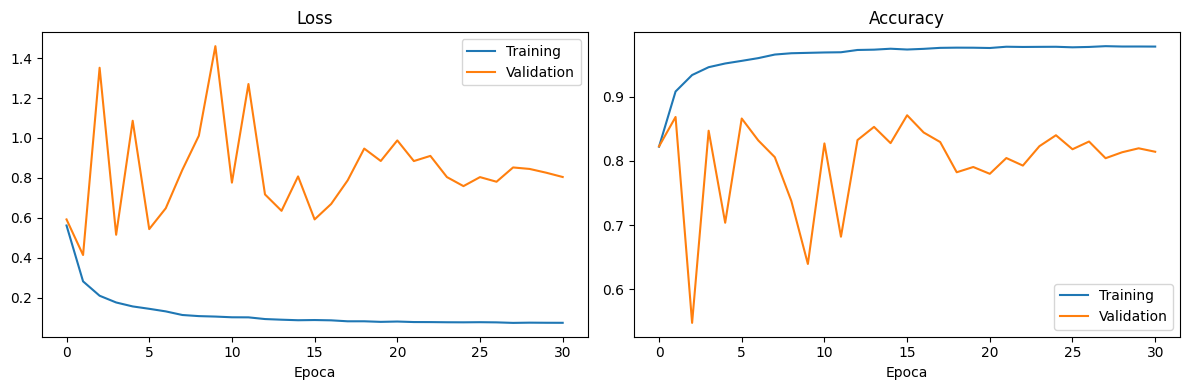

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Training')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoca')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Training')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoca')
axes[1].legend()

plt.tight_layout()
plt.show()

466/466 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


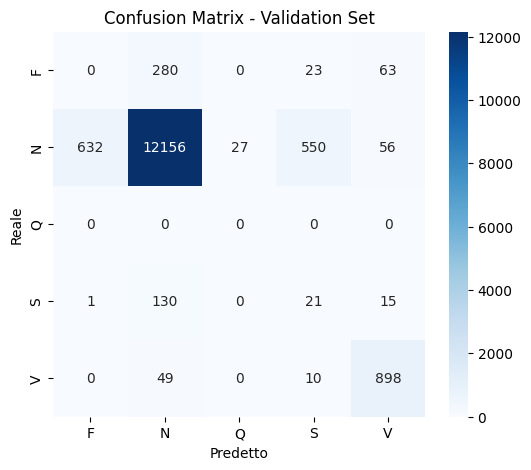

              precision    recall  f1-score   support

           F       0.00      0.00      0.00       366
           N       0.96      0.91      0.93     13421
           Q       0.00      0.00      0.00         0
           S       0.03      0.13      0.05       167
           V       0.87      0.94      0.90       957

    accuracy                           0.88     14911
   macro avg       0.37      0.39      0.38     14911
weighted avg       0.92      0.88      0.90     14911



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [35]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_val_pred = model.predict(X_val_r)
y_val_pred_classi = np.argmax(y_val_pred, axis=1)
y_val_vere = np.argmax(y_val_cat, axis=1)

nomi_classi = [int_to_classe[i] for i in range(num_classi)]

cm = confusion_matrix(y_val_vere, y_val_pred_classi)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=nomi_classi, yticklabels=nomi_classi, cmap='Blues')
plt.xlabel('Predetto')
plt.ylabel('Reale')
plt.title('Confusion Matrix - Validation Set')
plt.show()

print(classification_report(y_val_vere, y_val_pred_classi, target_names=nomi_classi))